ASSIGNMENT NLP – 5 (Token Classification: POS Tagging & Chunking)

Assignment: Fine-Tuning BERT for POS Tagging & Chunking




1. Install Dependencies

In [2]:
!pip install transformers datasets seqeval accelerate -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [1]:
from google.colab import files

uploaded = files.upload()

Saving dev.txt to dev.txt
Saving test.txt to test.txt
Saving train.txt to train.txt


STEP 2 — Define File Names

In [3]:
train_file = "train.txt"
dev_file = "dev.txt"
test_file = "test.txt"

STEP 3 — Read the CoNLL Files

In [4]:
def read_conll(file_path):
    sentences = []
    sentence = []

    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if not line:
                if sentence:
                    sentences.append(sentence)
                    sentence = []
            else:
                parts = line.split()
                word = parts[0]
                tag = parts[-1]
                sentence.append((word, tag))

    return sentences

In [5]:
train_data = read_conll(train_file)
dev_data = read_conll(dev_file)
test_data = read_conll(test_file)

STEP 4 — Separate Tokens and Labels

In [6]:
train_tokens = [[w for w, t in sent] for sent in train_data]
train_labels = [[t for w, t in sent] for sent in train_data]

dev_tokens = [[w for w, t in sent] for sent in dev_data]
dev_labels = [[t for w, t in sent] for sent in dev_data]

test_tokens = [[w for w, t in sent] for sent in test_data]
test_labels = [[t for w, t in sent] for sent in test_data]

STEP 5 — Create Label Mapping

In [7]:
unique_labels = list(set(tag for sent in train_labels for tag in sent))

label2id = {label: i for i, label in enumerate(unique_labels)}
id2label = {i: label for label, i in label2id.items()}

num_labels = len(unique_labels)

print("Number of labels:", num_labels)

Number of labels: 9


STEP 6 — Load BERT Tokenizer

In [8]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

STEP 7 — Tokenization + Label Alignment

In [9]:
def encode_data(sentences, labels):
    encoded_dataset = []

    for tokens, tags in zip(sentences, labels):

        tokenized = tokenizer(
            tokens,
            is_split_into_words=True,
            truncation=True
        )

        word_ids = tokenized.word_ids()

        previous_word_idx = None
        label_ids = []

        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(label2id[tags[word_idx]])
            else:
                label_ids.append(-100)

            previous_word_idx = word_idx

        tokenized["labels"] = label_ids
        encoded_dataset.append(tokenized)

    return encoded_dataset

In [10]:
from datasets import Dataset

train_dataset = Dataset.from_list(encode_data(train_tokens, train_labels))
dev_dataset = Dataset.from_list(encode_data(dev_tokens, dev_labels))
test_dataset = Dataset.from_list(encode_data(test_tokens, test_labels))

STEP 8 — Load BERT Model

In [11]:
from transformers import AutoModelForTokenClassification

model = AutoModelForTokenClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized be

STEP 9 — Define Evaluation Metric (F1 Score)

In [12]:
import numpy as np
from seqeval.metrics import precision_score, recall_score, f1_score

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_labels = []
    true_preds = []

    for pred, lab in zip(predictions, labels):
        temp_labels = []
        temp_preds = []

        for p_i, l_i in zip(pred, lab):
            if l_i != -100:
                temp_labels.append(id2label[l_i])
                temp_preds.append(id2label[p_i])

        true_labels.append(temp_labels)
        true_preds.append(temp_preds)

    return {
        "precision": precision_score(true_labels, true_preds),
        "recall": recall_score(true_labels, true_preds),
        "f1": f1_score(true_labels, true_preds)
    }

STEP 10 — Training Setup

In [13]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./bert_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    report_to="none"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


STEP 11 — Create Trainer

In [14]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    compute_metrics=compute_metrics
)

In [15]:
from transformers import DataCollatorForTokenClassification

In [16]:

data_collator = DataCollatorForTokenClassification(tokenizer)

In [17]:

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [18]:

print(train_dataset[0])

{'input_ids': [101, 1011, 9986, 14117, 2102, 1011, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1], 'labels': [-100, 5, -100, -100, -100, -100, -100]}


STEP 12 — Start Training

In [19]:
trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.067094,0.054382,0.927459,0.942444,0.934891
2,0.028372,0.050242,0.944323,0.947661,0.945989
3,0.015406,0.050553,0.941382,0.951363,0.946346


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5622, training_loss=0.052075684006974945, metrics={'train_runtime': 573.1903, 'train_samples_per_second': 78.44, 'train_steps_per_second': 9.808, 'total_flos': 936770898964122.0, 'train_loss': 0.052075684006974945, 'epoch': 3.0})

STEP 13 — Evaluate on Test Set

In [20]:
trainer.evaluate(test_dataset)

{'eval_loss': 0.1395522505044937,
 'eval_precision': 0.8964677222898904,
 'eval_recall': 0.9121813031161473,
 'eval_f1': 0.9042562527424308,
 'eval_runtime': 9.4835,
 'eval_samples_per_second': 388.465,
 'eval_steps_per_second': 48.611,
 'epoch': 3.0}

STEP 14 — Save the Model

In [21]:
trainer.save_model("./final_model")
tokenizer.save_pretrained("./final_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./final_model/tokenizer_config.json', './final_model/tokenizer.json')

STEP 15 — Run Inference

In [22]:
import torch

# Ensure model is on the same device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

sentence = "John works at Google in California"

tokens = sentence.split()

# Tokenize
inputs = tokenizer(
    tokens,
    is_split_into_words=True,
    return_tensors="pt"
)

# Move inputs to device
inputs = {k: v.to(device) for k, v in inputs.items()}

# Disable gradients
with torch.no_grad():
    outputs = model(**inputs)

# Get predictions
predictions = torch.argmax(outputs.logits, dim=2)

# Get word alignment properly
word_ids = tokenizer(tokens, is_split_into_words=True).word_ids()

predicted_tags = []
previous_word_idx = None

for idx, pred in zip(word_ids, predictions[0].cpu()):
    if idx is None:
        continue
    if idx != previous_word_idx:
        predicted_tags.append(id2label[pred.item()])
    previous_word_idx = idx

print("Tokens:", tokens)
print("Predicted Tags:", predicted_tags)

Tokens: ['John', 'works', 'at', 'Google', 'in', 'California']
Predicted Tags: ['B-PER', 'O', 'O', 'B-ORG', 'O', 'B-LOC']


STEP 16 — Comparison Section

In [23]:
from google.colab import files
uploaded = files.upload()

Saving Comparision.png to Comparision.png


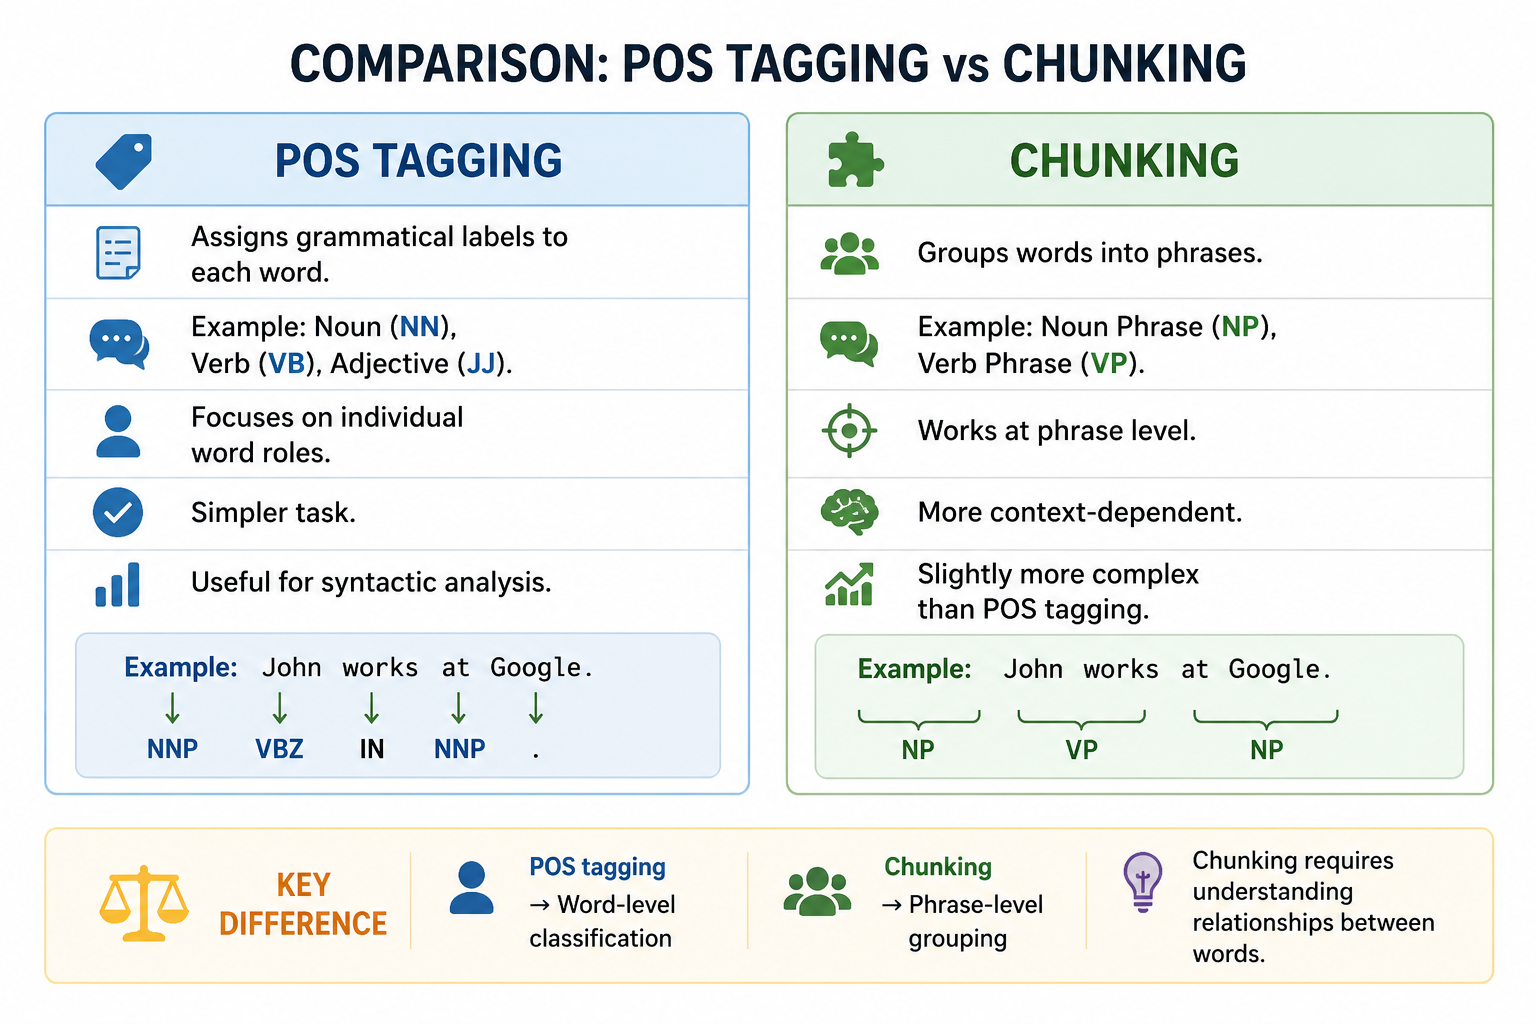

In [24]:
from IPython.display import Image
Image("Comparision.png")